# Fundamental frequency detection



This notebook shows a compact $f_0$-tracking workflow. It:


1. estimates the fundamental frequency frame by frame with `f0Detection`,

2. plots the detected $f_0$ contour on top of the spectrogram,

3. synthesizes the detected contour with `sinewaveSynth`,

4. and plays both the original sound and the synthesized $f_0$ signal.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import IPython.display as ipd
from scipy.signal import get_window
from smstools.models import harmonicModel as HM
from smstools.models import stft
from smstools.models import utilFunctions as UF


## 1. Load the cello phrase and track $f_0$

This example uses `harmonicModel.f0Detection()` from `sms-tools`, which internally applies the TWM-based fundamental-frequency detector frame by frame.


In [ ]:
input_file = '../sounds/cello-phrase.wav'
window = 'blackman'
M = 1201
N = 2048
H = 128
t = -80
minf0 = 250
maxf0 = 550
f0et = 5
fs, x = UF.wavread(input_file)
w = get_window(window, M)
print(f'Sampling rate: {fs} Hz')
print(f'Duration: {len(x) / fs:.2f} s')
ipd.display(ipd.Audio(data=x, rate=fs))


Sampling rate: 44100 Hz
Duration: 8.48 s


## 2. Plot the detected $f_0$ on top of the spectrogram

Frames analyzed: 2923
Voiced frames: 2912


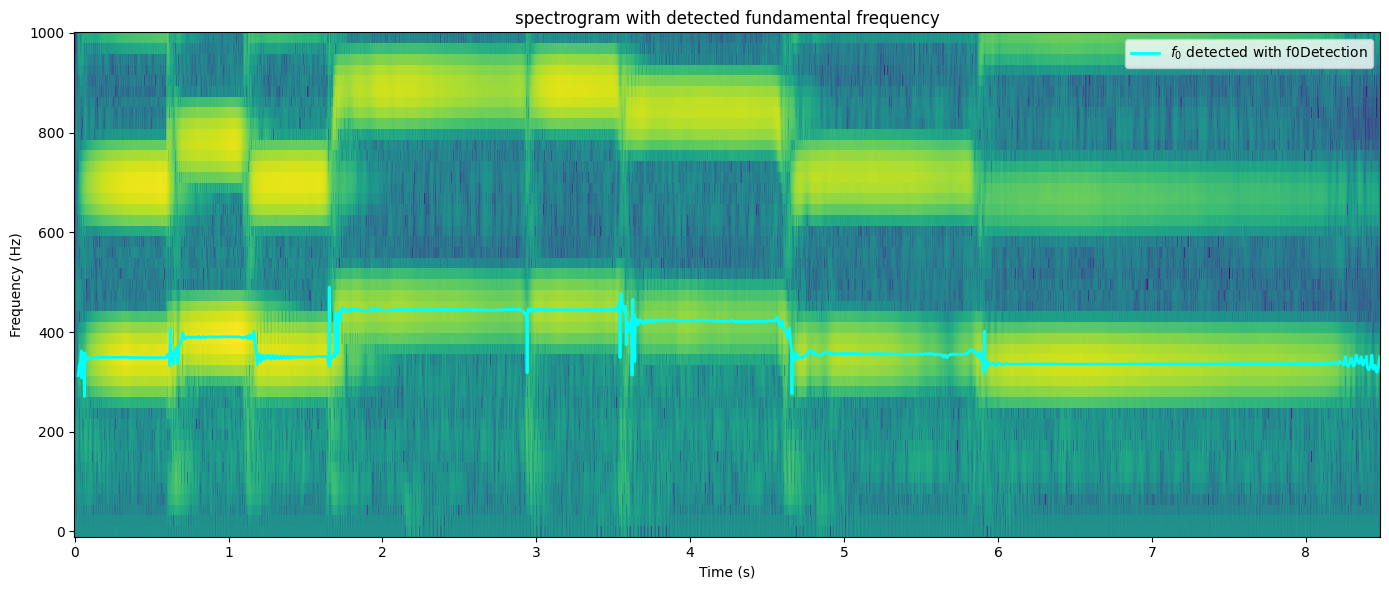

In [ ]:
f0 = HM.f0Detection(x, fs, w, N, H, t, minf0, maxf0, f0et)
frame_times = H * np.arange(f0.size) / float(fs)
print(f'Frames analyzed: {f0.size}')
print(f'Voiced frames: {np.count_nonzero(f0)}')
maxplotfreq = 1000.0
mX, _ = stft.stftAnal(x, w, N, H)
max_bin = int(N * maxplotfreq / fs) + 1
mX_plot = mX[:, :max_bin].T
binFreqs = np.arange(mX_plot.shape[0]) * fs / float(N)
f0_plot = np.where(f0 > 0, f0, np.nan)
plt.figure(figsize=(14, 6))
plt.pcolormesh(frame_times, binFreqs, mX_plot, shading='auto')
plt.plot(frame_times, f0_plot, color='cyan', linewidth=2.0, label='$f_0$ detected with f0Detection')
plt.xlabel('Time (s)')
plt.ylabel('Frequency (Hz)')
plt.title('spectrogram with detected fundamental frequency')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()


## 3. Synthesize the detected contour with `sinewaveSynth`

`sinewaveSynth` turns the frame-wise $f_0$ sequence into a simple sinusoidal signal, which makes it easy to listen to the pitch track alone.

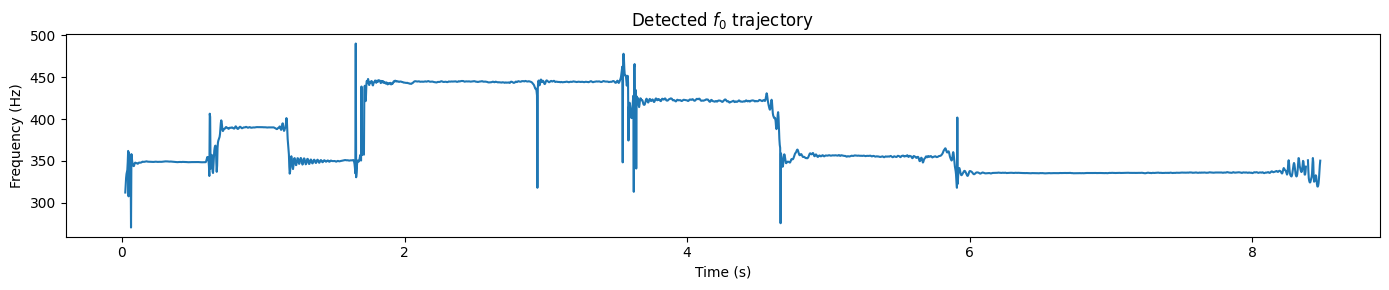

Original cello phrase:


Synthesized $f_0$ trajectory:


In [ ]:
y_f0 = UF.sinewaveSynth(f0, 0.8, H, fs)
print('Synthesized $f_0$ trajectory:')
ipd.display(ipd.Audio(data=y_f0, rate=fs))
